<a href="https://colab.research.google.com/github/PrashAI/myprojectr/blob/master/HClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [ ]:
Univ = pd.read_csv('/content/Universities.csv')
Univ.head()

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,1310,89,22,13,22704,94
1,CalTech,1415,100,25,6,63575,81
2,CMU,1260,62,59,9,25026,72
3,Columbia,1310,76,24,12,31510,88
4,Cornell,1280,83,33,13,21864,90


**Normalization Function**

In [ ]:
def norm_func(i):
    x = (i-i.min())/(i.max()-i.min())
    return (x)

In [ ]:
# Normalized data frame (considering the numerical part of data)
df_norm = norm_func(Univ.iloc[:,1:])\
df_norm

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,0.743902,0.847222,0.105263,0.368421,0.255144,0.900000
1,1.000000,1.000000,0.144737,0.000000,1.000000,0.466667
2,0.621951,0.472222,0.592105,0.157895,0.297461,0.166667
3,0.743902,0.666667,0.131579,0.315789,0.415629,0.700000
4,0.670732,0.763889,0.250000,0.368421,0.239835,0.766667
5,0.817073,0.847222,0.118421,0.210526,0.427512,0.933333
6,0.756098,0.861111,0.210526,0.315789,0.416996,0.933333
7,0.609756,0.638889,0.131579,0.315789,0.208161,0.833333
8,0.963415,0.875000,0.000000,0.263158,0.561699,1.000000
9,0.731707,0.652778,0.394737,0.052632,0.910991,0.666667


In [ ]:

from sklearn.preprocessing import MinMaxScaler
trans = MinMaxScaler()
data = pd.DataFrame(trans.fit_transform(Univ.iloc[:,1:]))
data

,0,1,2,3,4,5
0,0.743902,0.847222,0.105263,0.368421,0.255144,0.900000
1,1.000000,1.000000,0.144737,0.000000,1.000000,0.466667
2,0.621951,0.472222,0.592105,0.157895,0.297461,0.166667
3,0.743902,0.666667,0.131579,0.315789,0.415629,0.700000
4,0.670732,0.763889,0.250000,0.368421,0.239835,0.766667
5,0.817073,0.847222,0.118421,0.210526,0.427512,0.933333
6,0.756098,0.861111,0.210526,0.315789,0.416996,0.933333
7,0.609756,0.638889,0.131579,0.315789,0.208161,0.833333
8,0.963415,0.875000,0.000000,0.263158,0.561699,1.000000
9,0.731707,0.652778,0.394737,0.052632,0.910991,0.666667


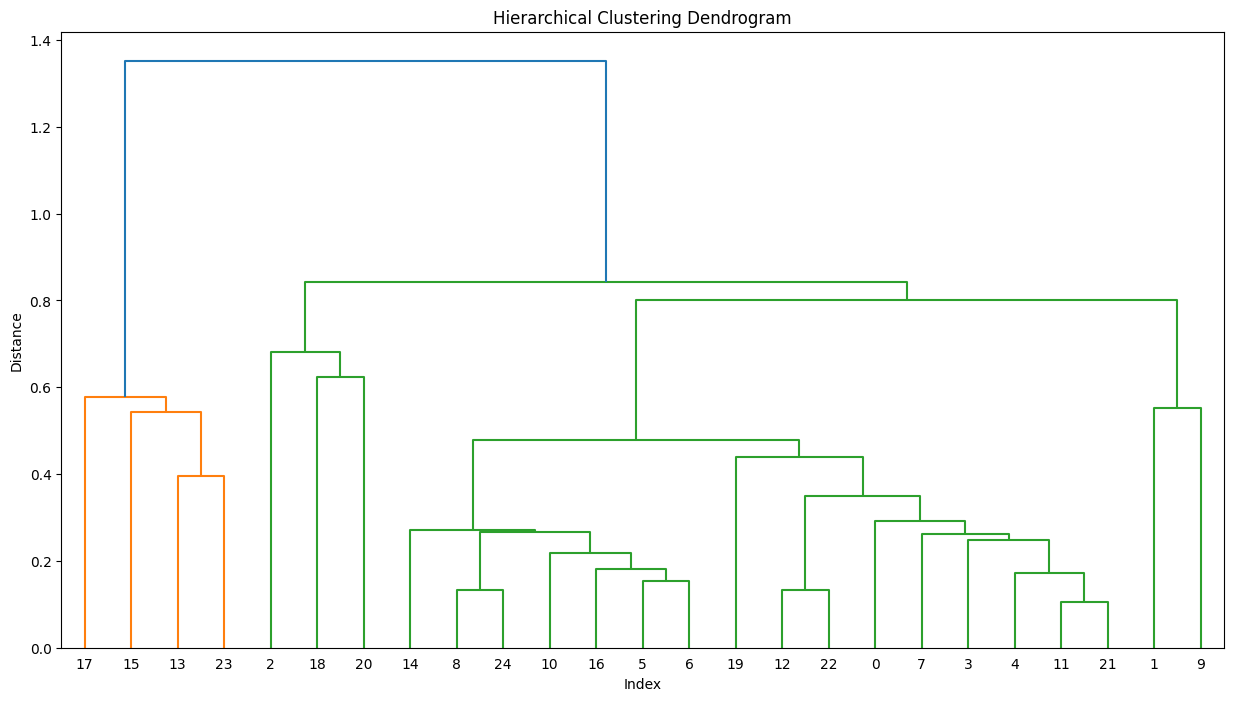

In [ ]:
from scipy.cluster.hierarchy import linkage
import scipy.cluster.hierarchy as sch
z = linkage(df_norm, method='average', metric='euclidean')
plt.figure(figsize=(15,8));plt.title('Hierarchical Clustering Dendrogram');plt.xlabel('Index');plt.ylabel('Distance')
sch.dendrogram(z,leaf_rotation=0,leaf_font_size=10)
plt.show()


In [ ]:
from sklearn.cluster import AgglomerativeClustering
import warnings
warnings.filterwarnings("ignore")
h_complete = AgglomerativeClustering(n_clusters=5, linkage='average').fit(df_norm)
cluster_label = pd.Series(h_complete.labels_)
Univ['cluster'] = cluster_label
Univ

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,cluster
0,Brown,1310,89,22,13,22704,94,3
1,CalTech,1415,100,25,6,63575,81,2
2,CMU,1260,62,59,9,25026,72,4
3,Columbia,1310,76,24,12,31510,88,3
4,Cornell,1280,83,33,13,21864,90,3
5,Dartmouth,1340,89,23,10,32162,95,3
6,Duke,1315,90,30,12,31585,95,3
7,Georgetown,1255,74,24,12,20126,92,3
8,Harvard,1400,91,14,11,39525,97,3
9,JohnsHopkins,1305,75,44,7,58691,87,2


In [ ]:
Univ.iloc[:,1:].groupby(Univ.cluster).mean()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate,cluster
cluster,,,,,,,
0,1210.0000,80.00,54.0,16.500,15305.000,81.500,0.0
1,1061.5000,38.75,70.0,19.250,9953.000,71.750,1.0
2,1360.0000,87.50,34.5,6.500,61133.000,84.000,2.0
3,1313.4375,85.00,29.0,11.625,29186.625,92.375,3.0
4,1260.0000,62.00,59.0,9.000,25026.000,72.000,4.0


In [ ]:
data = Univ[(Univ.cluster==1)]
data

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,cluster
13,PennState,1081,38,54,18,10185,80,1
15,Purdue,1005,28,90,19,9066,69,1
17,TexasA&M,1075,49,67,25,8704,67,1
23,UWisconsin,1085,40,69,15,11857,71,1


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(Univ.iloc[:,1:])
X_scaled_array = scaler.transform(Univ.iloc[:,1:])
X_scaled_array
data1 = pd.DataFrame(trans.fit_transform(Univ.iloc[:,1:]))
data1

,0,1,2,3,4,5,6
0,0.743902,0.847222,0.105263,0.368421,0.255144,0.900000,0.75
1,1.000000,1.000000,0.144737,0.000000,1.000000,0.466667,0.50
2,0.621951,0.472222,0.592105,0.157895,0.297461,0.166667,1.00
3,0.743902,0.666667,0.131579,0.315789,0.415629,0.700000,0.75
4,0.670732,0.763889,0.250000,0.368421,0.239835,0.766667,0.75
5,0.817073,0.847222,0.118421,0.210526,0.427512,0.933333,0.75
6,0.756098,0.861111,0.210526,0.315789,0.416996,0.933333,0.75
7,0.609756,0.638889,0.131579,0.315789,0.208161,0.833333,0.75
8,0.963415,0.875000,0.000000,0.263158,0.561699,1.000000,0.75
9,0.731707,0.652778,0.394737,0.052632,0.910991,0.666667,0.50


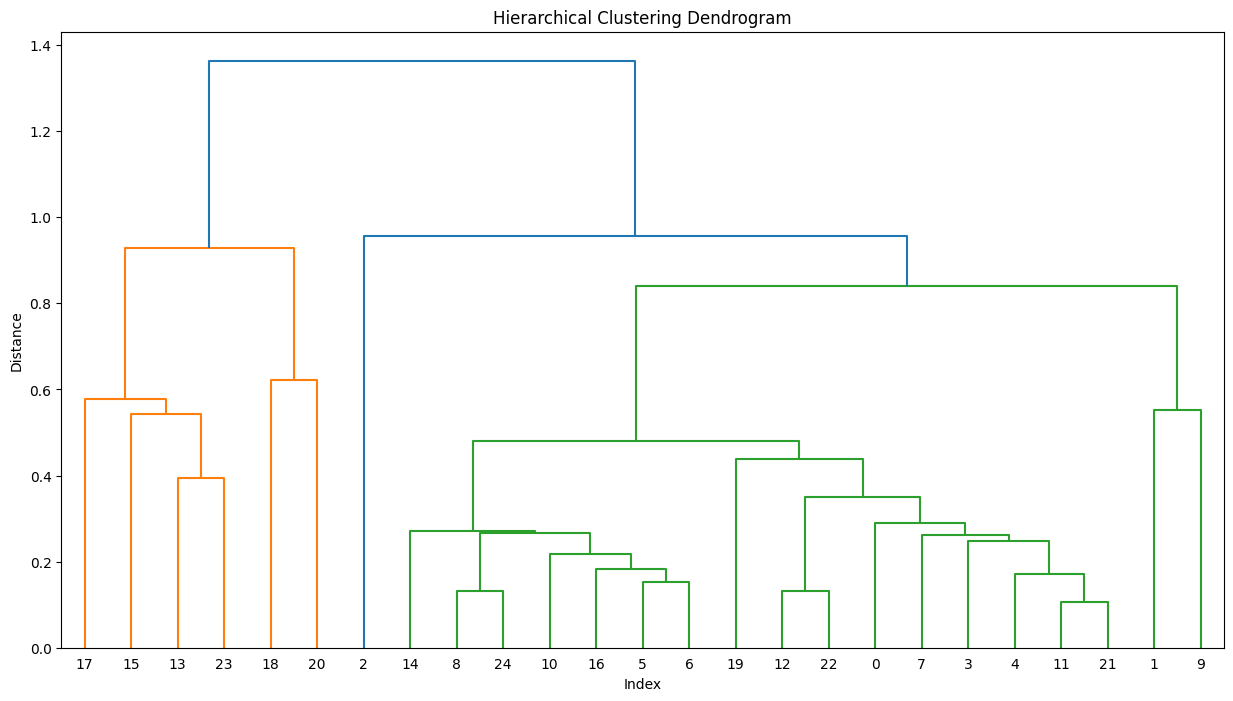

In [ ]:
from scipy.cluster.hierarchy import linkage
import scipy.cluster.hierarchy as sch
z = linkage(data1, method='average', metric='euclidean')
plt.figure(figsize=(15,8));plt.title('Hierarchical Clustering Dendrogram');plt.xlabel('Index');plt.ylabel('Distance')
sch.dendrogram(z,leaf_rotation=0,leaf_font_size=10)
plt.show()


In [ ]:
from sklearn.cluster import AgglomerativeClustering
import warnings
warnings.filterwarnings("ignore")
h_complete = AgglomerativeClustering(n_clusters=5, linkage='average').fit(df_norm)
cluster_label = pd.Series(h_complete.labels_)
Univ['cluster'] = cluster_label
Univ


,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,cluster
0,Brown,1310,89,22,13,22704,94,3
1,CalTech,1415,100,25,6,63575,81,2
2,CMU,1260,62,59,9,25026,72,4
3,Columbia,1310,76,24,12,31510,88,3
4,Cornell,1280,83,33,13,21864,90,3
5,Dartmouth,1340,89,23,10,32162,95,3
6,Duke,1315,90,30,12,31585,95,3
7,Georgetown,1255,74,24,12,20126,92,3
8,Harvard,1400,91,14,11,39525,97,3
9,JohnsHopkins,1305,75,44,7,58691,87,2


In [ ]:
Univ.iloc[:,1:].groupby(Univ.cluster).mean()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate,cluster
cluster,,,,,,,
0,1210.0000,80.00,54.0,16.500,15305.000,81.500,0.0
1,1061.5000,38.75,70.0,19.250,9953.000,71.750,1.0
2,1360.0000,87.50,34.5,6.500,61133.000,84.000,2.0
3,1313.4375,85.00,29.0,11.625,29186.625,92.375,3.0
4,1260.0000,62.00,59.0,9.000,25026.000,72.000,4.0
